# 📊 Exploratory Data Analysis (EDA)
## Amazon Product Reviews — Business Case Project
---
This notebook explores the cleaned dataset generated by `preprocess.py`.  
The goal is to understand the data structure, distributions, and key patterns  
before building the classification, clustering, and summarization models.

## 1. 📦 Libraries

In [1]:
# Import core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default plot style and size
sns.set_theme(style="whitegrid")
# plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Libraries loaded")

✅ Libraries loaded


## 2. 🗂️ Raw Data — Initial Inspection

Before working with the preprocessed data, we inspect the **original raw file** (`amazon_reviews.csv`) to understand the starting point: number of columns, naming conventions, data types, missing values, and quality issues.

This section answers the question: *"What were we actually dealing with before cleaning?"* — and justifies every transformation applied in `preprocess.py`.

In [2]:
# Load the raw dataset — before any preprocessing has been applied
df_raw = pd.read_csv("../data/raw/amazon_reviews.csv", low_memory=False)

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nAll column names ({len(df_raw.columns)}):")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:>2}. {col}")

Shape: 5,000 rows × 24 columns

All column names (24):
   1. id
   2. dateAdded
   3. dateUpdated
   4. name
   5. asins
   6. brand
   7. categories
   8. primaryCategories
   9. imageURLs
  10. keys
  11. manufacturer
  12. manufacturerNumber
  13. reviews.date
  14. reviews.dateAdded
  15. reviews.dateSeen
  16. reviews.doRecommend
  17. reviews.id
  18. reviews.numHelpful
  19. reviews.rating
  20. reviews.sourceURLs
  21. reviews.text
  22. reviews.title
  23. reviews.username
  24. sourceURLs


In [3]:
# First 3 rows — what does a raw record look like?
df_raw.head(3)

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-09-18T00:00:00Z,2017...",False,NaN,0,3,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-07-07T00:00:00Z,2017...",True,NaN,0,5,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,4,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...


In [4]:
# Data types and non-null counts per column
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5000 non-null   str    
 1   dateAdded            5000 non-null   str    
 2   dateUpdated          5000 non-null   str    
 3   name                 5000 non-null   str    
 4   asins                5000 non-null   str    
 5   brand                5000 non-null   str    
 6   categories           5000 non-null   str    
 7   primaryCategories    5000 non-null   str    
 8   imageURLs            5000 non-null   str    
 9   keys                 5000 non-null   str    
 10  manufacturer         5000 non-null   str    
 11  manufacturerNumber   5000 non-null   str    
 12  reviews.date         5000 non-null   str    
 13  reviews.dateAdded    1052 non-null   str    
 14  reviews.dateSeen     5000 non-null   str    
 15  reviews.doRecommend  5000 non-null   bool   
 16 

In [5]:
# Missing values per column — ordered by severity
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
})

print(f"Total columns:             {len(df_raw.columns)}")
print(f"Columns with any null:     {(missing > 0).sum()}")
print(f"Columns fully populated:   {(missing == 0).sum()}")
print()
print(missing_df[missing_df["missing_count"] > 0].to_string())

Total columns:             24
Columns with any null:     4
Columns fully populated:   20

                   missing_count  missing_%
reviews.id                  4971       99.4
reviews.dateAdded           3948       79.0
reviews.title                 13        0.3
reviews.username               1        0.0


In [6]:
# --- Duplicates ---
n_dup = df_raw.duplicated(subset=["reviews.text", "name"]).sum()
print(f"Duplicate reviews (same text + product): {n_dup} ({n_dup / len(df_raw) * 100:.1f}%)")

# --- Unique values in key categorical columns ---
print(f"\nUnique values in categorical columns:")
for col in ["name", "brand", "primaryCategories", "categories"]:
    if col in df_raw.columns:
        print(f"  {col:<25}  {df_raw[col].nunique():>4} unique values")

# --- Messy categories column ---
print(f"\nSample of 'categories' (raw — comma-separated, needs cleaning):")
print(df_raw["categories"].dropna().head(5).to_string())

# --- Rating distribution in raw data ---
print(f"\nRaw 'reviews.rating' distribution (including NaN):")
print(df_raw["reviews.rating"].value_counts(dropna=False).sort_index().to_string())
print(f"\nRating dtype (raw): {df_raw['reviews.rating'].dtype}")

Duplicate reviews (same text + product): 195 (3.9%)

Unique values in categorical columns:
  name                         23 unique values
  brand                         1 unique values
  primaryCategories             4 unique values
  categories                   23 unique values

Sample of 'categories' (raw — comma-separated, needs cleaning):
0    Computers,Electronics Features,Tablets,Electro...
1    Computers,Electronics Features,Tablets,Electro...
2    Computers,Electronics Features,Tablets,Electro...
3    Computers,Electronics Features,Tablets,Electro...
4    Computers,Electronics Features,Tablets,Electro...

Raw 'reviews.rating' distribution (including NaN):
reviews.rating
1      63
2      54
3     197
4    1208
5    3478

Rating dtype (raw): int64


### 🔍 Raw Data — Key Issues Found

| Issue | Impact | Fix in `preprocess.py` |
|---|---|---|
| Missing `reviews.text` | Can't classify without text | `dropna(subset=["review_text", "rating"])` |
| Missing `reviews.rating` | Can't create sentiment label | `dropna(subset=["review_text", "rating"])` |
| Duplicate entries (same text + product) | Biases training data | `drop_duplicates(subset=["review_text", "product_name"])` |
| `categories` has comma-separated values | Ambiguous category per row | `split(",")[0]` — keep first value only |
| `reviews.rating` stored as float/object | Prevents numeric operations | `pd.to_numeric(errors="coerce")` |
| 11+ irrelevant columns (URLs, IDs, images…) | Noise in the dataset | `select_columns()` keeps 10 relevant columns |
| Mixed-case review text | Inconsistent tokenization | `.str.lower().str.strip()` |

**Result:** 5,000 raw rows → **4,805 clean rows** after preprocessing (195 removed, ~3.9%)

## 3. 📥 Load Clean Data
Loading the preprocessed CSV from `data/processed/reviews_clean.csv` (output of `preprocess.py`).

In [7]:
# Load the preprocessed dataset (output from preprocess.py)
df = pd.read_csv("../data/processed/reviews_clean.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (4805, 11)
Columns: ['product_name', 'brand', 'categories', 'primary_category', 'rating', 'review_text', 'review_title', 'recommended', 'helpful_votes', 'username', 'sentiment']


## 3. 👀 First Inspection
Quick look at the first rows, column names, and data types.

In [8]:
# Display the first 5 rows to understand the structure
df.head()

,product_name,brand,categories,primary_category,rating,review_text,review_title,recommended,helpful_votes,username,sentiment
0,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Computers,Electronics,3,i thought it would be as big as small paper bu...,Too small,False,0,llyyue,neutral
1,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Computers,Electronics,5,this kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,True,0,Charmi,positive
2,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Computers,Electronics,4,didnt know how much i'd use a kindle so went f...,Great for the price,True,0,johnnyjojojo,positive
3,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Computers,Electronics,5,i am 100 happy with my purchase. i caught it o...,A Great Buy,True,3,Kdperry,positive
4,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",Amazon,Computers,Electronics,5,solid entry level kindle. great for kids. gift...,Solid entry-level Kindle. Great for kids,True,0,Johnnyblack,positive


In [9]:
# Check data types and non-null counts per column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4805 entries, 0 to 4804
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   product_name      4805 non-null   str  
 1   brand             4805 non-null   str  
 2   categories        4805 non-null   str  
 3   primary_category  4805 non-null   str  
 4   rating            4805 non-null   int64
 5   review_text       4805 non-null   str  
 6   review_title      4794 non-null   str  
 7   recommended       4805 non-null   bool 
 8   helpful_votes     4805 non-null   int64
 9   username          4804 non-null   str  
 10  sentiment         4805 non-null   str  
dtypes: bool(1), int64(2), str(8)
memory usage: 1.7 MB


## 4. 📐 Descriptive Statistics
Summary of numerical columns: rating, helpful_votes, and review length.

In [10]:
# Summary statistics for numerical columns
df[['rating', 'helpful_votes']].describe()

,rating,helpful_votes
count,4805.000000,4805.000000
mean,4.597919,0.314880
std,0.726159,3.160783
min,1.000000,0.000000
25%,4.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,5.000000,105.000000


## 5. 🎭 Sentiment Distribution
How are reviews distributed across positive, neutral, and negative classes?  
> ⚠️ **Note:** The dataset is heavily imbalanced — this will need to be addressed during model training.

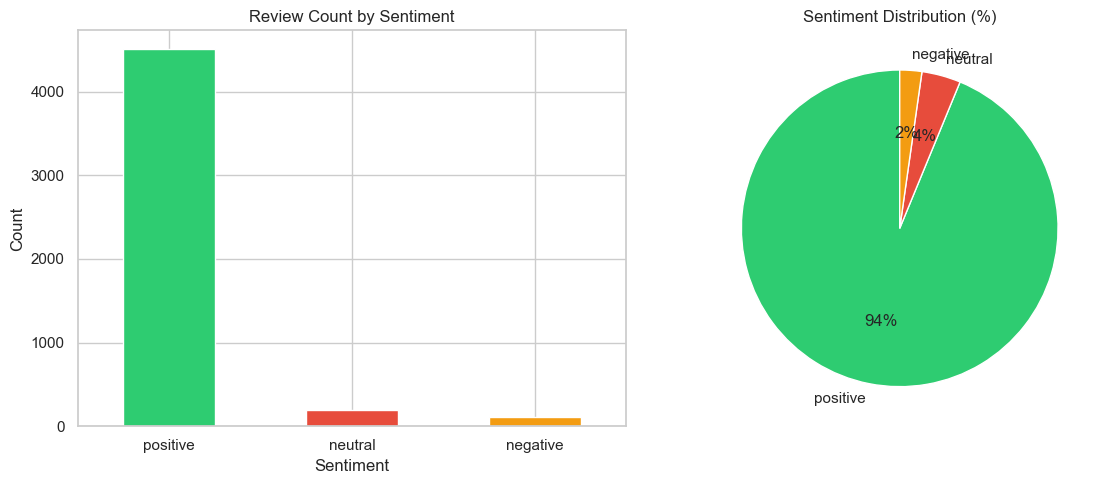

sentiment
positive    4506
neutral      191
negative     108
Name: count, dtype: int64


In [11]:
# Count reviews per sentiment class
sentiment_counts = df["sentiment"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sentiment_counts.plot(
    kind="bar",
    ax=axes[0],
    color=["#2ecc71", "#e74c3c", "#f39c12"],
    edgecolor="white"
)
axes[0].set_title("Review Count by Sentiment")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Pie chart
axes[1].pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.0f%%",
    colors=["#2ecc71", "#e74c3c", "#f39c12"],
    startangle=90
)
axes[1].set_title("Sentiment Distribution (%)")

plt.tight_layout()
plt.savefig("../data/processed/sentiment_distribution.png", dpi=150)
plt.show()

print(sentiment_counts)

## 6. ⭐ Star Rating Distribution
Distribution of raw star ratings (1 to 5) across all reviews.

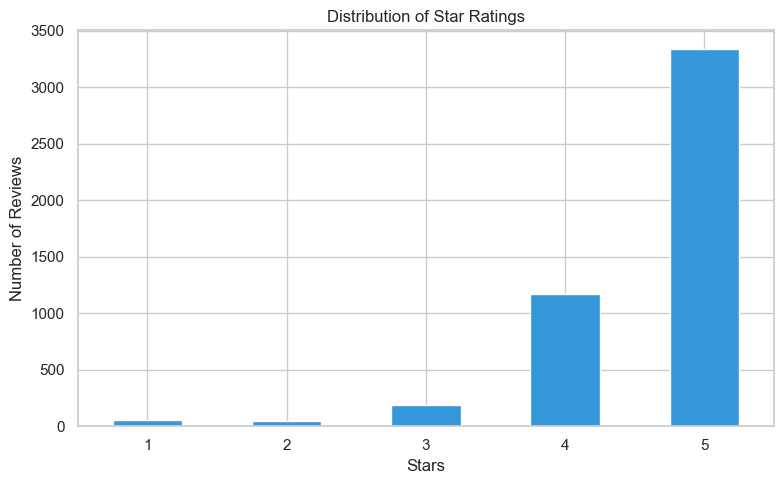

In [12]:
# Distribution of star ratings (1 to 5)
fig, ax = plt.subplots(figsize=(8, 5))

df["rating"].value_counts().sort_index().plot(
    kind="bar",
    ax=ax,
    color="#3498db",
    edgecolor="white"
)

ax.set_title("Distribution of Star Ratings")
ax.set_xlabel("Stars")
ax.set_ylabel("Number of Reviews")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../data/processed/rating_distribution.png", dpi=150)
plt.show()

## 7. 🏆 Top Reviewed Products
Since all reviews belong to Amazon products, we analyze by product name instead of brand.

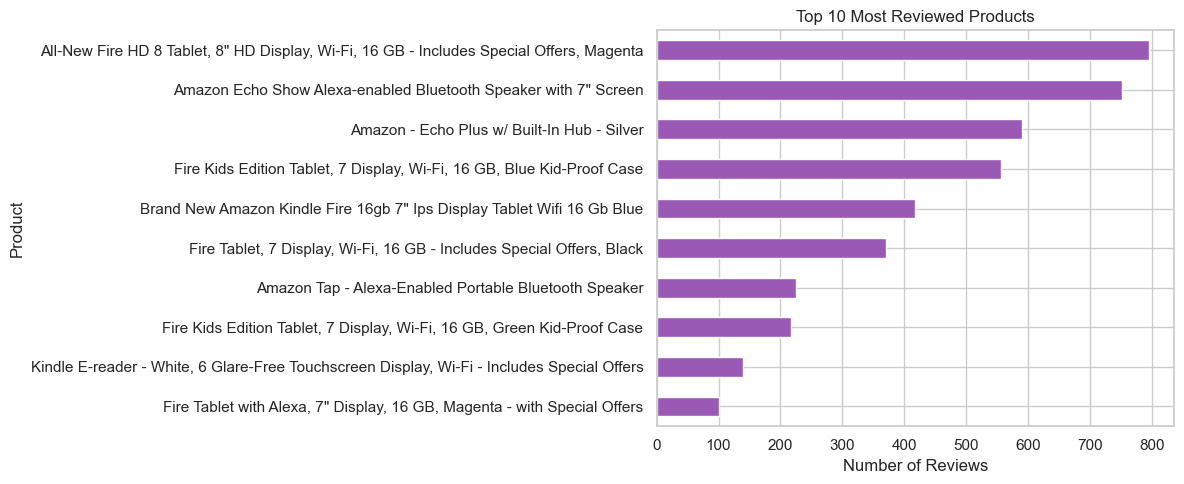

In [13]:
# Top 10 most reviewed products
# (we use product_name instead of brand since all brands are Amazon)
top_products = (
    df["product_name"]
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))

top_products.plot(
    kind="barh",
    ax=ax,
    color="#9b59b6",
    edgecolor="white"
)

ax.set_title("Top 10 Most Reviewed Products")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Product")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/top_products.png", dpi=150)
plt.show()

## 8. 📈 Average Rating by Product
Which products are rated highest on average?  
Only products with **50 or more reviews** are included for statistical reliability.

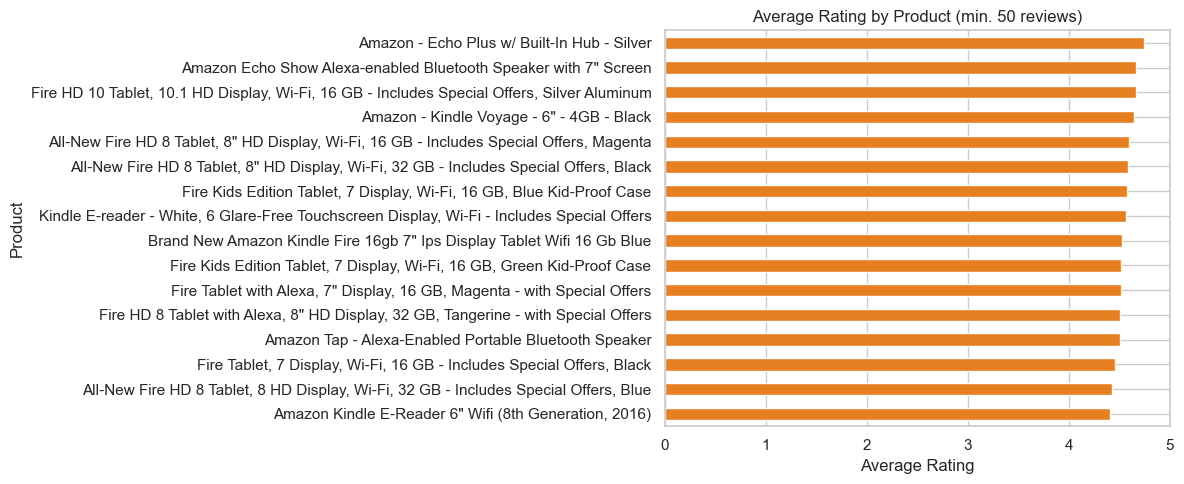

                                                    avg_rating  num_reviews
product_name                                                               
Amazon Kindle E-Reader 6" Wifi (8th Generation,...    4.406250           96
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, ...    4.432836           67
Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes...    4.460916          371
Amazon Tap - Alexa-Enabled Portable Bluetooth S...    4.506667          225
Fire HD 8 Tablet with Alexa, 8" HD Display, 32 ...    4.509434           53
Fire Tablet with Alexa, 7" Display, 16 GB, Mage...    4.514851          101
Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 ...    4.516129          217
Brand New Amazon Kindle Fire 16gb 7" Ips Displa...    4.531100          418
Kindle E-reader - White, 6 Glare-Free Touchscre...    4.571429          140
Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 ...    4.577338          556
All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi,...    4.586207           58
All-New Fire

In [14]:
# Average rating per product (only products with 50+ reviews)
avg_rating = (
    df.groupby("product_name")["rating"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_rating", "count": "num_reviews"})
    .query("num_reviews >= 50")
    .sort_values("avg_rating", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 5))

avg_rating["avg_rating"].plot( 
    kind="barh",
    ax=ax,
    color="#e67e22",
    edgecolor="white"
)

ax.set_title("Average Rating by Product (min. 50 reviews)")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Product")
ax.set_xlim(0, 5)

plt.tight_layout()
plt.savefig("../data/processed/avg_rating_by_product.png", dpi=150)
plt.show()

print(avg_rating)

## 8.1 📊 Rating Variability by Product
Do customers agree on the quality of each product, or are opinions divided?  
Error bars show the **standard deviation** of ratings — the wider the bar, the more divided the opinions.

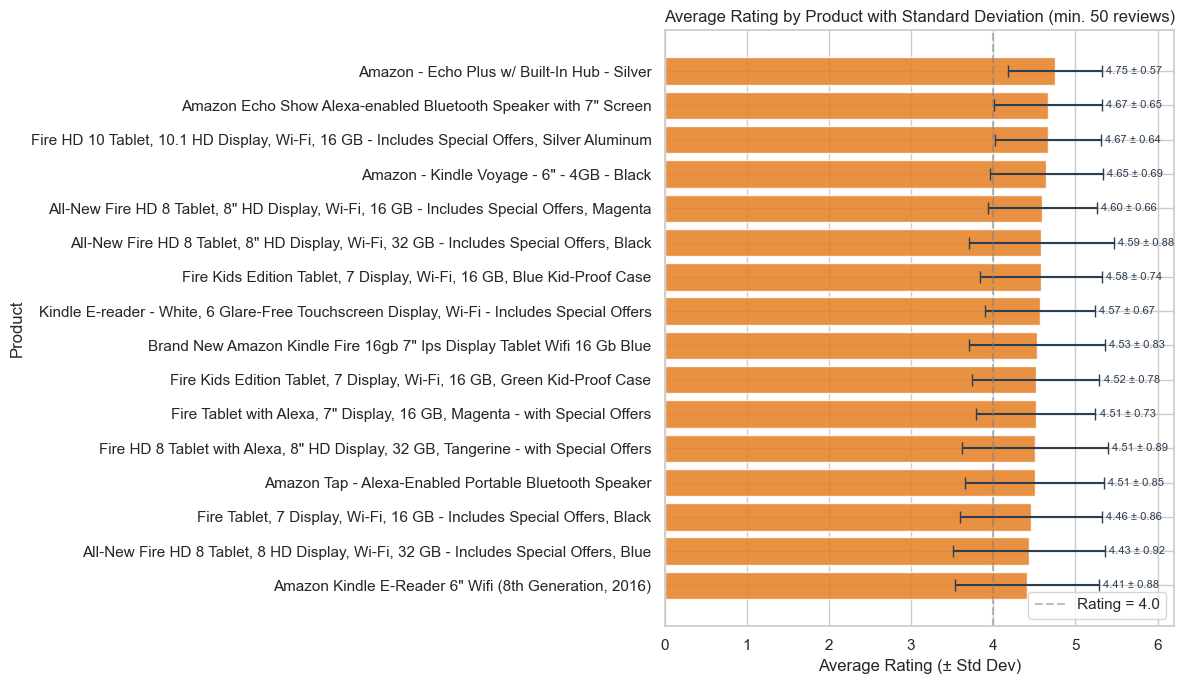

                                                                                             avg_rating  std_rating  num_reviews
product_name                                                                                                                    
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Blue           4.432836    0.924808           67
Fire HD 8 Tablet with Alexa, 8" HD Display, 32 GB, Tangerine - with Special Offers             4.509434    0.890606           53
All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 32 GB - Includes Special Offers, Black         4.586207    0.879284           58
Amazon Kindle E-Reader 6" Wifi (8th Generation, 2016)                                          4.406250    0.877534           96
Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includes Special Offers, Black                          4.460916    0.860834          371
Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker                                          4.

In [15]:
# Calculate mean and standard deviation of ratings per product
rating_stats = (
    df.groupby("product_name")["rating"]
    .agg(["mean", "std", "count"])
    .rename(columns={
        "mean":  "avg_rating",
        "std":   "std_rating",
        "count": "num_reviews"
    })
    .query("num_reviews >= 50")
    .sort_values("avg_rating", ascending=True)
)

# Plot with error bars
fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    rating_stats.index,
    rating_stats["avg_rating"],
    xerr=rating_stats["std_rating"],  # standard deviation as error bars
    color="#e67e22",
    ecolor="#2c3e50",                 # error bar color
    capsize=4,                        # width of the error bar caps
    edgecolor="white",
    alpha=0.85
)

# Add value labels at the end of each bar
for i, (avg, std) in enumerate(
    zip(rating_stats["avg_rating"], rating_stats["std_rating"])
):
    ax.text(
        avg + std + 0.05,             # position after the error bar
        i,
        f"{avg:.2f} ± {std:.2f}",    # format: mean ± std
        va="center",
        fontsize=8,
        color="#2c3e50"
    )

ax.set_title("Average Rating by Product with Standard Deviation (min. 50 reviews)")
ax.set_xlabel("Average Rating (± Std Dev)")
ax.set_ylabel("Product")
ax.set_xlim(0, 6.2)                   # extra space for labels
ax.axvline(x=4.0, color="gray",
           linestyle="--", alpha=0.5,
           label="Rating = 4.0")      # reference line
ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/rating_variability.png", dpi=150)
plt.show()

# Print table summary
print(rating_stats[["avg_rating", "std_rating", "num_reviews"]]
      .sort_values("std_rating", ascending=False)
      .to_string())

### 🔍 Key Insights — Rating Variability

- **Most divisive product:** Fire HD 8 (32GB) — good average but high disagreement among customers (std ~0.92)
- **Most consensus:** Amazon Echo Plus Silver — highest rating AND lowest std (4.75 ± 0.57)  
- **Echo devices** (Echo Plus, Echo Show) are the safest recommendations: high rating + low variability
- **Fire HD 8 variants** should be recommended with caution due to divided opinions
- The **Kindle E-Reader 6" (8th Gen)** has both the lowest average (4.41) and high variability — potential "avoid" candidate

## 9. 📏 Review Length Analysis
Do negative reviews tend to be longer than positive ones?  
People often write more when they are unhappy. Let's check.

/var/folders/v3/2dc085d933vb9z1qd81k7c8w0000gp/T/ipykernel_24077/1583319765.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


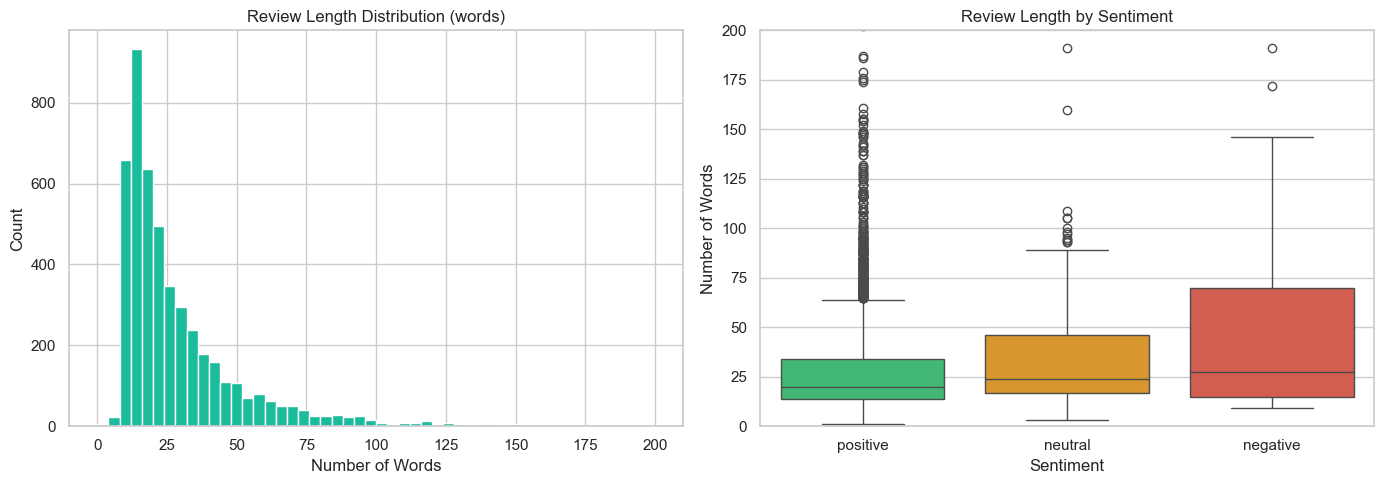

count    4805.000000
mean       30.906139
std        45.962327
min         1.000000
25%        14.000000
50%        21.000000
75%        35.000000
max      1539.000000
Name: review_length, dtype: float64


In [16]:
# Calculate number of words per review
df["review_length"] = df["review_text"].apply(
    lambda x: len(str(x).split())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    df["review_length"],
    bins=50,
    range=(0, 200),
    color="#1abc9c",
    edgecolor="white"
)
axes[0].set_title("Review Length Distribution (words)")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Count")

# Boxplot by sentiment
sns.boxplot(
    x="sentiment",
    y="review_length",
    data=df,
    ax=axes[1],
    palette={
        "positive": "#2ecc71",
        "neutral": "#f39c12",
        "negative": "#e74c3c"
    },
    order=["positive", "neutral", "negative"]
)
axes[1].set_title("Review Length by Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Number of Words")
axes[1].set_ylim(0, 200)   

plt.tight_layout()
plt.savefig("../data/processed/review_lengths.png", dpi=150)
plt.show()

print(df["review_length"].describe())

> ℹ️ The histogram and boxplot are clipped at 200 words. Approximately 4% of reviews 
> (those with more than 200 words) are not shown to improve readability.

## 10. 🎯 EDA Summary
Key takeaways from the exploratory analysis.

In [17]:
# Final summary of the cleaned dataset
print("=" * 55)
print("              EDA SUMMARY")
print("=" * 55)

# --- General info ---
print("📦 DATASET")
print(f"  Total reviews:          {len(df)}")
print(f"  Unique products:        {df['product_name'].nunique()}")
print(f"  Unique brands:          {df['brand'].nunique()}")
print(f"  Unique categories:      {df['primary_category'].nunique()}")

# --- Sentiment ---
print("\n🎭 SENTIMENT DISTRIBUTION")
for label, count in df["sentiment"].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {label:<12} {count:>5}  ({pct:.1f}%)")
print("  ⚠️  Heavy class imbalance — needs balancing in model training")

# --- Review length ---
print("\n📏 REVIEW LENGTH (words)")
print(f"  Mean:                   {df['review_length'].mean():.0f} words")
print(f"  Median:                 {df['review_length'].median():.0f} words")
print(f"  Std deviation:          {df['review_length'].std():.0f} words")
print(f"  Min:                    {df['review_length'].min()} words")
print(f"  Max:                    {df['review_length'].max()} words")
print(f"  75th percentile:        {df['review_length'].quantile(0.75):.0f} words")
print(f"  95th percentile:        {df['review_length'].quantile(0.95):.0f} words")
print("  ✅ Short reviews — 128 tokens will cover most cases for NLP models")

# --- Top products ---
print("\n🏆 TOP PRODUCTS")
top = df['product_name'].value_counts().head(3)
for i, (name, count) in enumerate(top.items(), 1):
    print(f"  {i}. {name[:55]:<55} ({count} reviews)")

# --- Most divisive product ---
divisive = (
    df.groupby("product_name")["rating"]
    .agg(["std", "count"])
    .query("count >= 50")
    .sort_values("std", ascending=False)
    .index[0]
)
print("\n⚠️  MOST DIVISIVE PRODUCT (highest std)")
print(f"  {divisive[:75]}")

# --- Most consistent product ---
consistent = (
    df.groupby("product_name")["rating"]
    .agg(["std", "count"])
    .query("count >= 50")
    .sort_values("std", ascending=True)
    .index[0]
)
print("\n✅ MOST CONSISTENT PRODUCT (lowest std)")
print(f"  {consistent[:75]}")

print("\n" + "=" * 55)
print("  💡 IMPLICATIONS FOR MODELING")
print("=" * 55)
print("  Classification:  Use 128 token truncation (covers 95th pct)")
print("  Classification:  Apply class_weight='balanced' (94/4/2 split)")
print("  Clustering:      4-6 clusters expected (e-readers,")
print("                   tablets, kids tablets, Alexa devices)")
print("  Summarization:   Concatenate short reviews per product")
print("=" * 55)

              EDA SUMMARY
📦 DATASET
  Total reviews:          4805
  Unique products:        23
  Unique brands:          1
  Unique categories:      2

🎭 SENTIMENT DISTRIBUTION
  positive      4506  (93.8%)
  neutral        191  (4.0%)
  negative       108  (2.2%)
  ⚠️  Heavy class imbalance — needs balancing in model training

📏 REVIEW LENGTH (words)
  Mean:                   31 words
  Median:                 21 words
  Std deviation:          46 words
  Min:                    1 words
  Max:                    1539 words
  75th percentile:        35 words
  95th percentile:        80 words
  ✅ Short reviews — 128 tokens will cover most cases for NLP models

🏆 TOP PRODUCTS
  1. All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi, 16 GB - (796 reviews)
  2. Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7 (751 reviews)
  3. Amazon - Echo Plus w/ Built-In Hub - Silver             (590 reviews)

⚠️  MOST DIVISIVE PRODUCT (highest std)
  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 